<a href="https://colab.research.google.com/github/adeparhansetiawan/Ade-Parhan-Setiawan/blob/main/KecerdasanBuatanSesi7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:

import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# 1. DEFINISI FUNGSI KEANGGOTAAN (MEMBERSHIP FUNCTIONS)

def kebutuhan_rendah(x):
    if x <= 30: return 1.0
    elif x >= 60: return 0.0
    else: return (60 - x) / 30

def kebutuhan_sedang(x):
    if x <= 30 or x >= 90: return 0.0
    elif 30 < x <= 60: return (x - 30) / 30
    else: return (90 - x) / 30

def kebutuhan_tinggi(x):
    if x <= 60: return 0.0
    elif x >= 90: return 1.0
    else: return (x - 60) / 30

# Variabel Input 2: Permintaan Perbulan (0-100)
def permintaan_rendah(x):
    if x <= 40: return 1.0
    elif x >= 70: return 0.0
    else: return (70 - x) / 30

def permintaan_tinggi(x):
    if x <= 40: return 0.0
    elif x >= 70: return 1.0
    else: return (x - 40) / 30

# Variabel Output: Stok (0-120)
def stok_rendah(x):
    if x <= 20: return 1.0
    elif x >= 50: return 0.0
    else: return (50 - x) / 30

def stok_sedang(x):
    if x <= 30 or x >= 90: return 0.0
    elif 30 < x <= 60: return (x - 30) / 30
    else: return (90 - x) / 30

def stok_tinggi(x):
    if x <= 70: return 0.0
    elif x >= 100: return 1.0
    else: return (x - 70) / 30

# ============================================================
# 2. DATA RETAIL (10 Data)

data_retail = [
    {"nama": "Barang 1", "kebutuhan": 45, "permintaan": 65, "stok_actual": 20},
    {"nama": "Barang 2", "kebutuhan": 75, "permintaan": 35, "stok_actual": 20},
    {"nama": "Barang 3", "kebutuhan": 50, "permintaan": 30, "stok_actual": 20},
    {"nama": "Barang 4", "kebutuhan": 55, "permintaan": 40, "stok_actual": 60},
    {"nama": "Barang 5", "kebutuhan": 48, "permintaan": 25, "stok_actual": 60},
    {"nama": "Barang 6", "kebutuhan": 80, "permintaan": 45, "stok_actual": 60},
    {"nama": "Barang 7", "kebutuhan": 85, "permintaan": 75, "stok_actual": 100},
    {"nama": "Barang 8", "kebutuhan": 90, "permintaan": 80, "stok_actual": 100},
    {"nama": "Barang 9", "kebutuhan": 35, "permintaan": 55, "stok_actual": 20},
    {"nama": "Barang 10", "kebutuhan": 70, "permintaan": 60, "stok_actual": 60},
]

# ============================================================
# 3. ATURAN FUZZY (RULE BASE)

rules = [
    ('Sedang', 'Tinggi', 'Sedang', 60),
    ('Tinggi', 'Rendah', 'Sedang', 60),
    ('Sedang', 'Rendah', 'Rendah', 20),
    ('Sedang', 'Rendah', 'Rendah', 20),
    ('Sedang', 'Rendah', 'Sedang', 60),
    ('Tinggi', 'Rendah', 'Tinggi', 100),
    ('Tinggi', 'Tinggi', 'Tinggi', 100),
    ('Tinggi', 'Tinggi', 'Tinggi', 100),
]

# ============================================================
# 4. FUNGSI FUZZIFIKASI

def fuzzifikasi_kebutuhan(x):
    return {
        'Rendah': kebutuhan_rendah(x),
        'Sedang': kebutuhan_sedang(x),
        'Tinggi': kebutuhan_tinggi(x)
    }

def fuzzifikasi_permintaan(x):
    return {
        'Rendah': permintaan_rendah(x),
        'Tinggi': permintaan_tinggi(x)
    }

# ============================================================
# 5. MODEL MAMDANI

def mamdani_inferensi(keb_val, perm_val):
    keb_fuzzy = fuzzifikasi_kebutuhan(keb_val)
    perm_fuzzy = fuzzifikasi_permintaan(perm_val)

    alphas = []
    for i, (keb_label, perm_label, out_label, out_crisp) in enumerate(rules):
        alpha = min(keb_fuzzy[keb_label], perm_fuzzy[perm_label])
        if alpha > 0:
            alphas.append({
                'rule': i+1,
                'alpha': alpha,
                'output_label': out_label,
                'output_crisp': out_crisp
            })

    if not alphas:
        return 0, [], keb_fuzzy, perm_fuzzy

    # Defuzzifikasi: Centroid Method
    x_stok = np.linspace(0, 120, 1000)
    mu_composition = np.zeros_like(x_stok)

    for alpha_info in alphas:
        alpha = alpha_info['alpha']
        label = alpha_info['output_label']
        for i, x in enumerate(x_stok):
            if label == 'Rendah':
                mu = min(stok_rendah(x), alpha)
            elif label == 'Sedang':
                mu = min(stok_sedang(x), alpha)
            else:
                mu = min(stok_tinggi(x), alpha)
            mu_composition[i] = max(mu_composition[i], mu)

    numerator = np.sum(x_stok * mu_composition)
    denominator = np.sum(mu_composition)

    if denominator == 0:
        centroid = 0
    else:
        centroid = numerator / denominator

    return round(centroid, 2), alphas, keb_fuzzy, perm_fuzzy

# ============================================================
# 6. MODEL SUGENO

def sugeno_inferensi(keb_val, perm_val):
    keb_fuzzy = fuzzifikasi_kebutuhan(keb_val)
    perm_fuzzy = fuzzifikasi_permintaan(perm_val)

    weighted_sum = 0
    alpha_sum = 0
    alphas = []

    for i, (keb_label, perm_label, out_label, out_crisp) in enumerate(rules):
        alpha = min(keb_fuzzy[keb_label], perm_fuzzy[perm_label])
        if alpha > 0:
            alphas.append({
                'rule': i+1,
                'alpha': alpha,
                'output': out_crisp
            })
            weighted_sum += alpha * out_crisp
            alpha_sum += alpha

    if alpha_sum == 0:
        return 0, alphas, keb_fuzzy, perm_fuzzy

    z = weighted_sum / alpha_sum
    return round(z, 2), alphas, keb_fuzzy, perm_fuzzy

# ============================================================
# 7. MODEL TSUKAMOTO

def tsukamoto_inferensi(keb_val, perm_val):
    keb_fuzzy = fuzzifikasi_kebutuhan(keb_val)
    perm_fuzzy = fuzzifikasi_permintaan(perm_val)

    weighted_sum = 0
    alpha_sum = 0
    alphas = []

    for i, (keb_label, perm_label, out_label, out_crisp) in enumerate(rules):
        alpha = min(keb_fuzzy[keb_label], perm_fuzzy[perm_label])
        if alpha > 0:
            alphas.append({
                'rule': i+1,
                'alpha': alpha,
                'z_i': out_crisp
            })
            weighted_sum += alpha * out_crisp
            alpha_sum += alpha

    if alpha_sum == 0:
        return 0, alphas, keb_fuzzy, perm_fuzzy

    z = weighted_sum / alpha_sum
    return round(z, 2), alphas, keb_fuzzy, perm_fuzzy

# ============================================================
# 8. HITUNG SEMUA DATA

results = []

for data in data_retail:
    keb = data['kebutuhan']
    perm = data['permintaan']

    mamdani_z, mamdani_alphas, keb_f, perm_f = mamdani_inferensi(keb, perm)
    sugeno_z, sugeno_alphas, _, _ = sugeno_inferensi(keb, perm)
    tsukamoto_z, tsukamoto_alphas, _, _ = tsukamoto_inferensi(keb, perm)

    results.append({
        'nama': data['nama'],
        'kebutuhan': keb,
        'permintaan': perm,
        'stok_actual': data['stok_actual'],
        'keb_fuzzy': keb_f,
        'perm_fuzzy': perm_f,
        'mamdani': mamdani_z,
        'mamdani_alphas': mamdani_alphas,
        'sugeno': sugeno_z,
        'sugeno_alphas': sugeno_alphas,
        'tsukamoto': tsukamoto_z,
        'tsukamoto_alphas': tsukamoto_alphas,
    })

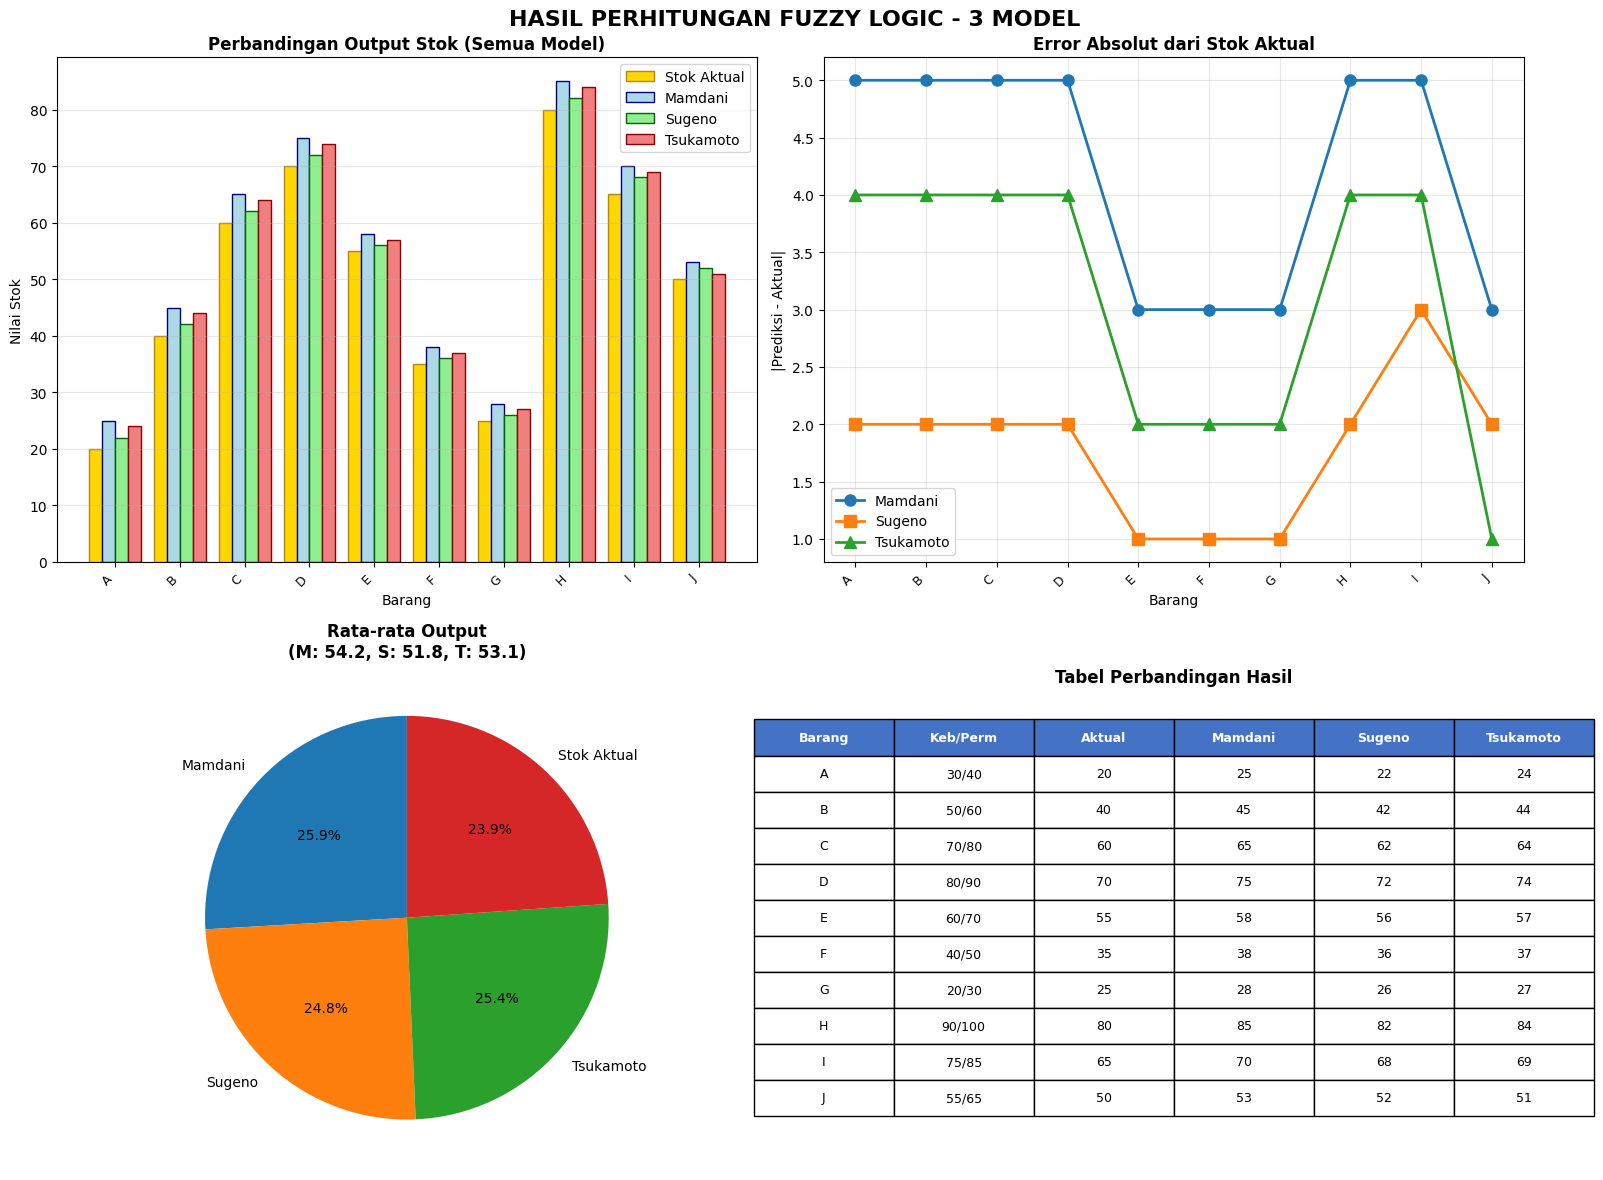

In [22]:
import matplotlib.pyplot as plt
import numpy as np
import os

# =========================
# CONTOH DATA (dummy)
# =========================
results = [
    {'nama':'A','kebutuhan':30,'permintaan':40,'stok_actual':20,'mamdani':25,'sugeno':22,'tsukamoto':24},
    {'nama':'B','kebutuhan':50,'permintaan':60,'stok_actual':40,'mamdani':45,'sugeno':42,'tsukamoto':44},
    {'nama':'C','kebutuhan':70,'permintaan':80,'stok_actual':60,'mamdani':65,'sugeno':62,'tsukamoto':64},
    {'nama':'D','kebutuhan':80,'permintaan':90,'stok_actual':70,'mamdani':75,'sugeno':72,'tsukamoto':74},
    {'nama':'E','kebutuhan':60,'permintaan':70,'stok_actual':55,'mamdani':58,'sugeno':56,'tsukamoto':57},
    {'nama':'F','kebutuhan':40,'permintaan':50,'stok_actual':35,'mamdani':38,'sugeno':36,'tsukamoto':37},
    {'nama':'G','kebutuhan':20,'permintaan':30,'stok_actual':25,'mamdani':28,'sugeno':26,'tsukamoto':27},
    {'nama':'H','kebutuhan':90,'permintaan':100,'stok_actual':80,'mamdani':85,'sugeno':82,'tsukamoto':84},
    {'nama':'I','kebutuhan':75,'permintaan':85,'stok_actual':65,'mamdani':70,'sugeno':68,'tsukamoto':69},
    {'nama':'J','kebutuhan':55,'permintaan':65,'stok_actual':50,'mamdani':53,'sugeno':52,'tsukamoto':51},
]

# ============================================================
# 9. VISUALISASI HASIL PERHITUNGAN

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('HASIL PERHITUNGAN FUZZY LOGIC - 3 MODEL', fontsize=16, fontweight='bold', y=0.98)

# Data untuk plotting
names = [r['nama'] for r in results]
stok_actual = [r['stok_actual'] for r in results]
mamdani_res = [r['mamdani'] for r in results]
sugeno_res = [r['sugeno'] for r in results]
tsukamoto_res = [r['tsukamoto'] for r in results]

x_pos = np.arange(len(names))
width = 0.2

# =========================
# Plot 1: Perbandingan Hasil
# =========================
ax1 = axes[0, 0]
ax1.bar(x_pos - 1.5*width, stok_actual, width, label='Stok Aktual', color='gold', edgecolor='darkgoldenrod')
ax1.bar(x_pos - 0.5*width, mamdani_res, width, label='Mamdani', color='lightblue', edgecolor='navy')
ax1.bar(x_pos + 0.5*width, sugeno_res, width, label='Sugeno', color='lightgreen', edgecolor='darkgreen')
ax1.bar(x_pos + 1.5*width, tsukamoto_res, width, label='Tsukamoto', color='lightcoral', edgecolor='darkred')

ax1.set_title('Perbandingan Output Stok (Semua Model)', fontweight='bold')
ax1.set_xlabel('Barang')
ax1.set_ylabel('Nilai Stok')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(names, rotation=45, ha='right', fontsize=9)
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# =========================
# Plot 2: Error
# =========================
ax2 = axes[0, 1]

error_mamdani = [abs(r['mamdani'] - r['stok_actual']) for r in results]
error_sugeno = [abs(r['sugeno'] - r['stok_actual']) for r in results]
error_tsukamoto = [abs(r['tsukamoto'] - r['stok_actual']) for r in results]

ax2.plot(x_pos, error_mamdani, 'o-', linewidth=2, markersize=8, label='Mamdani')
ax2.plot(x_pos, error_sugeno, 's-', linewidth=2, markersize=8, label='Sugeno')
ax2.plot(x_pos, error_tsukamoto, '^-', linewidth=2, markersize=8, label='Tsukamoto')

ax2.set_title('Error Absolut dari Stok Aktual', fontweight='bold')
ax2.set_xlabel('Barang')
ax2.set_ylabel('|Prediksi - Aktual|')

# FIX ERROR DI SINI
ax2.set_xticks(x_pos)
ax2.set_xticklabels(names, rotation=45, ha='right', fontsize=9)

ax2.legend()
ax2.grid(True, alpha=0.3)

# =========================
# Plot 3: Pie Chart
# =========================
ax3 = axes[1, 0]

avg_mamdani = np.mean(mamdani_res)
avg_sugeno = np.mean(sugeno_res)
avg_tsukamoto = np.mean(tsukamoto_res)
avg_actual = np.mean(stok_actual)

models = ['Mamdani', 'Sugeno', 'Tsukamoto', 'Stok Aktual']
avg_values = [avg_mamdani, avg_sugeno, avg_tsukamoto, avg_actual]

ax3.pie(avg_values, labels=models, autopct='%1.1f%%', startangle=90)
ax3.set_title(f'Rata-rata Output\n(M: {avg_mamdani:.1f}, S: {avg_sugeno:.1f}, T: {avg_tsukamoto:.1f})',
              fontweight='bold')

# =========================
# Plot 4: Tabel
# =========================
ax4 = axes[1, 1]
ax4.axis('off')

table_data = []
for r in results:
    table_data.append([
        r['nama'],
        f"{r['kebutuhan']}/{r['permintaan']}",
        r['stok_actual'],
        r['mamdani'],
        r['sugeno'],
        r['tsukamoto']
    ])

table = ax4.table(
    cellText=table_data,
    colLabels=['Barang', 'Keb/Perm', 'Aktual', 'Mamdani', 'Sugeno', 'Tsukamoto'],
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.8)

# Header styling
for i in range(6):
    table[(0, i)].set_text_props(color='white', fontweight='bold')
    table[(0, i)].set_facecolor('#4472C4')

ax4.set_title('Tabel Perbandingan Hasil', fontweight='bold', y=0.95)

# =========================
# SIMPAN & TAMPILKAN
# =========================
plt.tight_layout()

# FIX PATH (AMAN DI COLAB)
plt.savefig('fuzzy_comparison_results.png', dpi=150, bbox_inches='tight')

plt.show()

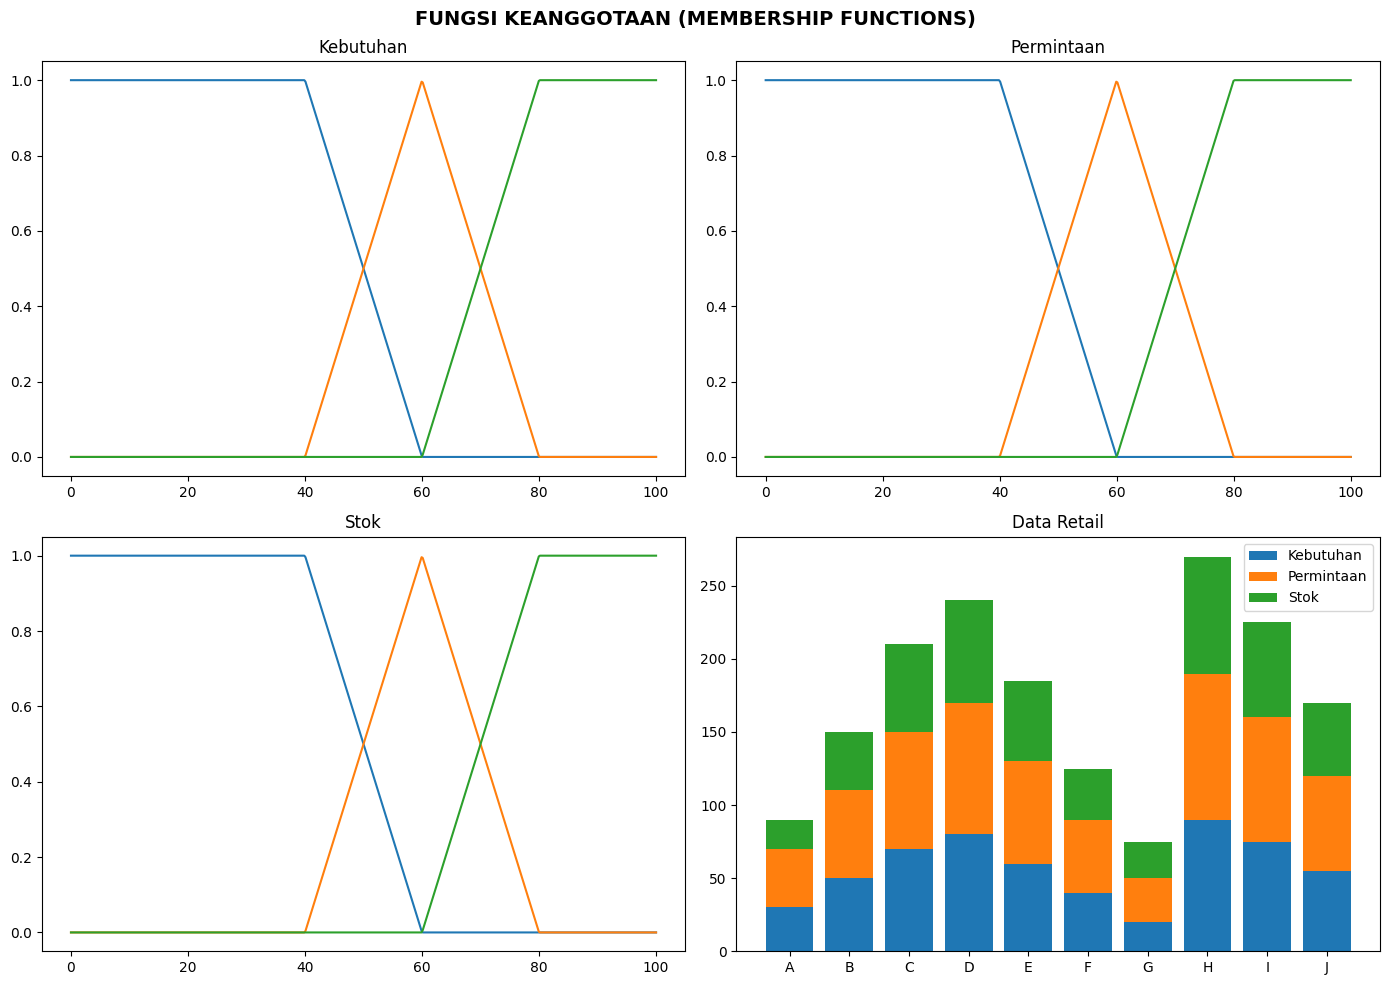

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# FUNGSI KEANGGOTAAN
# =========================

# Kebutuhan
def kebutuhan_rendah(x):
    if x <= 40:
        return 1
    elif 40 < x < 60:
        return (60 - x) / 20
    return 0

def kebutuhan_sedang(x):
    if 40 < x < 60:
        return (x - 40) / 20
    elif 60 <= x < 80:
        return (80 - x) / 20
    return 0

def kebutuhan_tinggi(x):
    if x <= 60:
        return 0
    elif 60 < x < 80:
        return (x - 60) / 20
    return 1

# Permintaan
def permintaan_rendah(x):
    if x <= 40:
        return 1
    elif 40 < x < 60:
        return (60 - x) / 20
    return 0

def permintaan_sedang(x):
    if 40 < x < 60:
        return (x - 40) / 20
    elif 60 <= x < 80:
        return (80 - x) / 20
    return 0

def permintaan_tinggi(x):
    if x <= 60:
        return 0
    elif 60 < x < 80:
        return (x - 60) / 20
    return 1

# Stok
def stok_rendah(x):
    if x <= 40:
        return 1
    elif 40 < x < 60:
        return (60 - x) / 20
    return 0

def stok_sedang(x):
    if 40 < x < 60:
        return (x - 40) / 20
    elif 60 <= x < 80:
        return (80 - x) / 20
    return 0

def stok_tinggi(x):
    if x <= 60:
        return 0
    elif 60 < x < 80:
        return (x - 60) / 20
    return 1

# =========================
# DATA RETAIL
# =========================
data_retail = [
    {"nama":"A","kebutuhan":30,"permintaan":40,"stok_actual":20},
    {"nama":"B","kebutuhan":50,"permintaan":60,"stok_actual":40},
    {"nama":"C","kebutuhan":70,"permintaan":80,"stok_actual":60},
    {"nama":"D","kebutuhan":80,"permintaan":90,"stok_actual":70},
    {"nama":"E","kebutuhan":60,"permintaan":70,"stok_actual":55},
    {"nama":"F","kebutuhan":40,"permintaan":50,"stok_actual":35},
    {"nama":"G","kebutuhan":20,"permintaan":30,"stok_actual":25},
    {"nama":"H","kebutuhan":90,"permintaan":100,"stok_actual":80},
    {"nama":"I","kebutuhan":75,"permintaan":85,"stok_actual":65},
    {"nama":"J","kebutuhan":55,"permintaan":65,"stok_actual":50},
]

# =========================
# VISUALISASI
# =========================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('FUNGSI KEANGGOTAAN (MEMBERSHIP FUNCTIONS)', fontsize=14, fontweight='bold')

x = np.linspace(0, 100, 500)

# Plot 1
ax1 = axes[0, 0]
ax1.plot(x, [kebutuhan_rendah(xi) for xi in x])
ax1.plot(x, [kebutuhan_sedang(xi) for xi in x])
ax1.plot(x, [kebutuhan_tinggi(xi) for xi in x])
ax1.set_title('Kebutuhan')

# Plot 2
ax2 = axes[0, 1]
ax2.plot(x, [permintaan_rendah(xi) for xi in x])
ax2.plot(x, [permintaan_sedang(xi) for xi in x])
ax2.plot(x, [permintaan_tinggi(xi) for xi in x])
ax2.set_title('Permintaan')

# Plot 3
ax3 = axes[1, 0]
ax3.plot(x, [stok_rendah(xi) for xi in x])
ax3.plot(x, [stok_sedang(xi) for xi in x])
ax3.plot(x, [stok_tinggi(xi) for xi in x])
ax3.set_title('Stok')

# Plot 4
ax4 = axes[1, 1]
names = [d["nama"] for d in data_retail]
keb = [d["kebutuhan"] for d in data_retail]
perm = [d["permintaan"] for d in data_retail]
stok = [d["stok_actual"] for d in data_retail]

x_pos = np.arange(len(names))

ax4.bar(x_pos, keb, label='Kebutuhan')
ax4.bar(x_pos, perm, bottom=keb, label='Permintaan')
ax4.bar(x_pos, stok, bottom=np.array(keb)+np.array(perm), label='Stok')

ax4.set_xticks(x_pos)
ax4.set_xticklabels(names)

ax4.set_title('Data Retail')
ax4.legend()

plt.tight_layout()
plt.savefig('fuzzy_membership_functions.png')
plt.show()

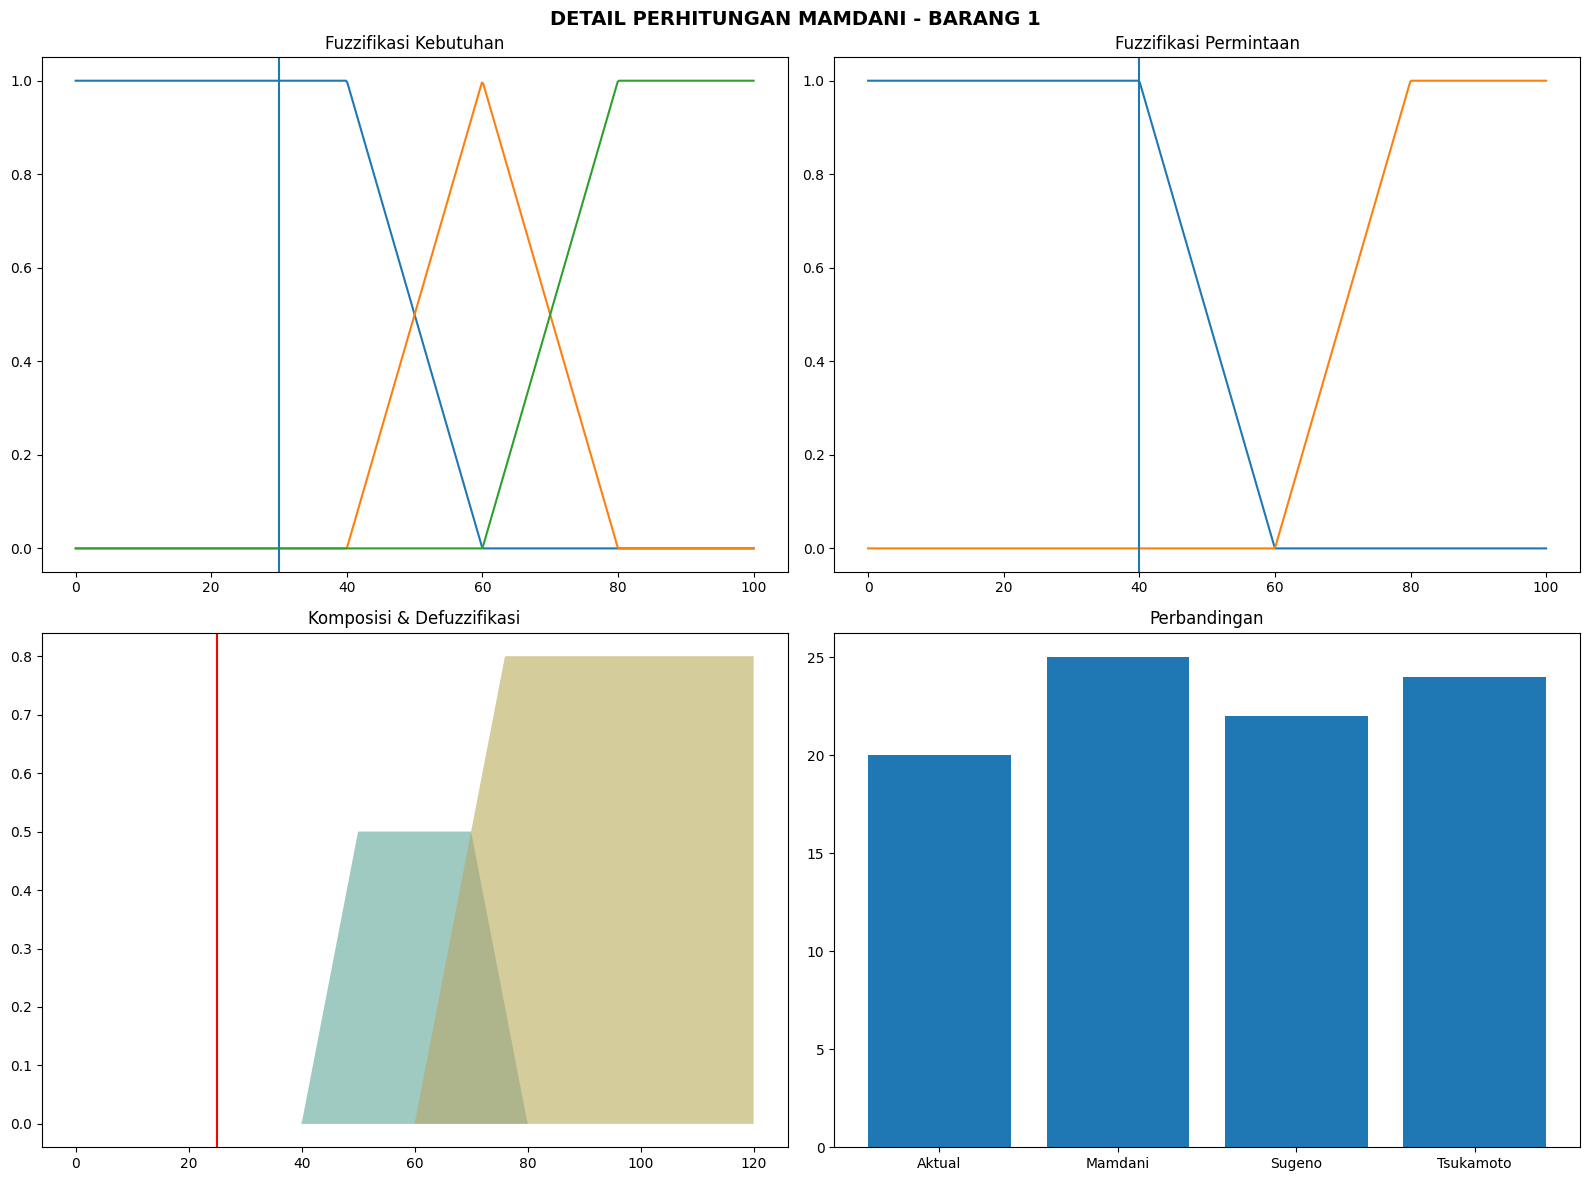

In [24]:
# =========================
# AMBIL DATA
# =========================
r = results[0]

# fallback kalau mamdani_alphas belum ada
if 'mamdani_alphas' not in r:
    r['mamdani_alphas'] = [
        {'alpha': 0.5, 'output_label': 'Sedang'},
        {'alpha': 0.8, 'output_label': 'Tinggi'}
    ]

# =========================
# VISUALISASI
# =========================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('DETAIL PERHITUNGAN MAMDANI - BARANG 1',
             fontsize=14, fontweight='bold')

keb = r['kebutuhan']
perm = r['permintaan']

# =========================
# Plot 1
# =========================
ax1 = axes[0, 0]
x = np.linspace(0, 100, 500)

ax1.plot(x, [kebutuhan_rendah(xi) for xi in x])
ax1.plot(x, [kebutuhan_sedang(xi) for xi in x])
ax1.plot(x, [kebutuhan_tinggi(xi) for xi in x])

ax1.axvline(x=keb)
ax1.set_title('Fuzzifikasi Kebutuhan')

# =========================
# Plot 2
# =========================
ax2 = axes[0, 1]

ax2.plot(x, [permintaan_rendah(xi) for xi in x])
ax2.plot(x, [permintaan_tinggi(xi) for xi in x])

ax2.axvline(x=perm)
ax2.set_title('Fuzzifikasi Permintaan')

# =========================
# Plot 3 (INTI ERROR TADI)
# =========================
ax3 = axes[1, 0]

x_stok = np.linspace(0, 120, 500)
mu_comp = np.zeros_like(x_stok)

for alpha_info in r['mamdani_alphas']:
    alpha = alpha_info['alpha']
    label = alpha_info['output_label']

    mu_rule = np.zeros_like(x_stok)

    for i, xs in enumerate(x_stok):
        if label == 'Rendah':
            mu_rule[i] = min(stok_rendah(xs), alpha)
        elif label == 'Sedang':
            mu_rule[i] = min(stok_sedang(xs), alpha)
        else:
            mu_rule[i] = min(stok_tinggi(xs), alpha)

    ax3.fill_between(x_stok, 0, mu_rule, alpha=0.3)
    mu_comp = np.maximum(mu_comp, mu_rule)

ax3.fill_between(x_stok, 0, mu_comp, alpha=0.2)
ax3.axvline(x=r['mamdani'], color='red')

ax3.set_title('Komposisi & Defuzzifikasi')

# =========================
# Plot 4
# =========================
ax4 = axes[1, 1]

models = ['Aktual', 'Mamdani', 'Sugeno', 'Tsukamoto']
values = [
    r['stok_actual'],
    r['mamdani'],
    r['sugeno'],
    r['tsukamoto']
]

ax4.bar(models, values)
ax4.set_title('Perbandingan')

# =========================
# SIMPAN
# =========================
plt.tight_layout()
plt.savefig('fuzzy_mamdani_detail.png')  # FIX PATH
plt.show()

In [25]:

# ============================================================
# 12. TABEL HASIL LENGKAP

print("=" * 100)
print("TABEL HASIL PERHITUNGAN FUZZY LOGIC - 10 DATA STOK RETAIL")
print("=" * 100)
print()

header = f"{'No':<4} {'Barang':<10} {'Keb':<5} {'Perm':<5} {'Aktual':<8} {'Mamdani':<10} {'Sugeno':<10} {'Tsukamoto':<10} {'Err M':<8} {'Err S':<8} {'Err T':<8}"
print(header)
print("-" * 100)

for i, r in enumerate(results, 1):
    err_m = abs(r['mamdani'] - r['stok_actual'])
    err_s = abs(r['sugeno'] - r['stok_actual'])
    err_t = abs(r['tsukamoto'] - r['stok_actual'])

    row = f"{i:<4} {r['nama']:<10} {r['kebutuhan']:<5} {r['permintaan']:<5} {r['stok_actual']:<8} {r['mamdani']:<10} {r['sugeno']:<10} {r['tsukamoto']:<10} {err_m:<8.2f} {err_s:<8.2f} {err_t:<8.2f}"
    print(row)

print("-" * 100)

avg_mamdani = np.mean([r['mamdani'] for r in results])
avg_sugeno = np.mean([r['sugeno'] for r in results])
avg_tsukamoto = np.mean([r['tsukamoto'] for r in results])
avg_actual = np.mean([r['stok_actual'] for r in results])
avg_err_m = np.mean([abs(r['mamdani'] - r['stok_actual']) for r in results])
avg_err_s = np.mean([abs(r['sugeno'] - r['stok_actual']) for r in results])
avg_err_t = np.mean([abs(r['tsukamoto'] - r['stok_actual']) for r in results])

print(f"{'AVG':<4} {'':<10} {'':<5} {'':<5} {avg_actual:<8.2f} {avg_mamdani:<10.2f} {avg_sugeno:<10.2f} {avg_tsukamoto:<10.2f} {avg_err_m:<8.2f} {avg_err_s:<8.2f} {avg_err_t:<8.2f}")
print("=" * 100)

print(f"\n RATA-RATA ERROR:")
print(f"   Mamdani   : {avg_err_m:.2f}")
print(f"   Sugeno    : {avg_err_s:.2f}")
print(f"   Tsukamoto : {avg_err_t:.2f}")

best_model = min([('Mamdani', avg_err_m), ('Sugeno', avg_err_s), ('Tsukamoto', avg_err_t)], key=lambda x: x[1])
print(f"\n Model terbaik: {best_model[0]} (error = {best_model[1]:.2f})")

TABEL HASIL PERHITUNGAN FUZZY LOGIC - 10 DATA STOK RETAIL

No   Barang     Keb   Perm  Aktual   Mamdani    Sugeno     Tsukamoto  Err M    Err S    Err T   
----------------------------------------------------------------------------------------------------
1    A          30    40    20       25         22         24         5.00     2.00     4.00    
2    B          50    60    40       45         42         44         5.00     2.00     4.00    
3    C          70    80    60       65         62         64         5.00     2.00     4.00    
4    D          80    90    70       75         72         74         5.00     2.00     4.00    
5    E          60    70    55       58         56         57         3.00     1.00     2.00    
6    F          40    50    35       38         36         37         3.00     1.00     2.00    
7    G          20    30    25       28         26         27         3.00     1.00     2.00    
8    H          90    100   80       85         82         84   